# 01. SID 分布分析（懂物料 / 懂推荐 生成侧词表画像）

> 对应 `analysis_plan.md` §2.1。

**输入**：`dataset_rec_all/data/OneReason_Pid2Sid/*.parquet`  
**Schema**：`pid: int64`, `domain: string`, `sid_three: list<float>=[s_a, s_b, s_c]`  
**规模**：198 个 parquet × 20 万行 ≈ 4000 万条 pid ↔ SID 映射。

**四大产出**：
1. **词表大小与桶数** —— 每个 domain × level 的 unique token 数、id 范围、跨 domain 是否共用 codebook。
2. **频率分布** —— PDF/CDF、top-1% token 覆盖率、长尾比例。
3. **联合 / 条件分布** —— `P(s_b|s_a)` 和 `P(s_c|s_a,s_b)` 的条件熵；三元组是否碰撞（不同 pid → 同 SID）。
4. **跨域共现** —— 同一 (s_a,s_b,s_c) 是否在多个 domain 出现（决定是否共用 codebook）。

**这些结论直接指导 SFT**：
- 长尾 token → 训练时上采样；
- 层级性（`s_a` 是否强预测 `s_b`）→ 推理时 prefix constrained decoding、beam 宽度；
- 跨域共用 → 负采样与 domain 前缀设计。

> 首次执行会全量扫描 4000 万行（几分钟量级），中间结果会 pickle 到 `outputs/sid/_cache.pkl`，之后重跑秒级完成。
> 想快速试跑改 `SAMPLE_FRAC = 0.02`。

In [11]:
# ============ 配置 & imports ============
import os
import pickle
import math
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# ---- 路径 ----
PROJECT_ROOT = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
PID2SID_DIR  = PROJECT_ROOT / 'dataset_rec_all' / 'data' / 'OneReason_Pid2Sid'
OUT_DIR      = PROJECT_ROOT / 'analysis' / 'outputs' / 'sid'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH   = OUT_DIR / '_cache.pkl'

# ---- 参数 ----
SAMPLE_FRAC   = 1.0     # 想快速试跑改成 0.02
USE_CACHE     = True    # 有缓存就直接读，跳过全量扫描
BATCH_ROWS    = 200_000 # 每次读一个 row group
LEVELS        = ['s_a', 's_b', 's_c']

print('Pid2Sid dir      :', PID2SID_DIR)
print('Output dir       :', OUT_DIR)
print('Cache path       :', CACHE_PATH)
print('Sample fraction  :', SAMPLE_FRAC)

parquet_files = sorted(PID2SID_DIR.glob('part-*.parquet'))
print(f'#parquet files   : {len(parquet_files)}')
print('first parquet    :', parquet_files[0].name if parquet_files else None)

Pid2Sid dir      : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Sid
Output dir       : /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid
Cache path       : /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/_cache.pkl
Sample fraction  : 1.0
#parquet files   : 198
first parquet    : part-00000.parquet


## 单次全量扫描：一遍 IO 收集所有需要的中间统计

为了避免多次读 4000 万行，这里在 **一次遍历** 内同时收集：
- `freq[domain][level][token_id]` —— 一维频次；
- `pair_ab[domain][s_a] -> Counter(s_b)` —— (s_a → s_b) 条件分布；
- `triple_cnt[domain][(s_a,s_b,s_c)]` —— 三元组出现次数（用于 pid 碰撞率）；
- `triple_domains[(s_a,s_b,s_c)] -> set(domain)` —— 跨域共现（内存受限，采用 hash 抽样：只跟踪 SAMPLE_FRAC 的三元组）；
- `total_rows[domain]` —— 每域行数。

In [12]:
def _empty_stats():
    return {
        'freq':           defaultdict(lambda: [Counter(), Counter(), Counter()]),  # domain -> [Counter(s_a), Counter(s_b), Counter(s_c)]
        'pair_ab':        defaultdict(lambda: defaultdict(Counter)),                # domain -> s_a -> Counter(s_b)
        'pair_abc':       defaultdict(lambda: defaultdict(Counter)),                # domain -> (s_a,s_b) -> Counter(s_c)
        'triple_cnt':     defaultdict(Counter),                                     # domain -> Counter((s_a,s_b,s_c))
        'triple_domains': defaultdict(set),                                          # (s_a,s_b,s_c) -> set(domain)   (仅前 X 桶哈希采样)
        'total_rows':     Counter(),                                                # domain -> row cnt
    }


def scan_all(parquet_files, sample_frac=1.0, cross_hash_mod=100, cross_hash_keep=1):
    """Single-pass full scan.

    cross_hash_mod / cross_hash_keep: 只保留 hash(triple)%mod < keep 的三元组的 domain 集合，
    用于跨域共现估计（默认保留 1%），控制内存。
    """
    stats = _empty_stats()
    t0 = time.time()
    for i, fp in enumerate(parquet_files):
        pf = pq.ParquetFile(fp)
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=['domain', 'sid_three'])
            df = tbl.to_pandas()
            if sample_frac < 1.0:
                df = df.sample(frac=sample_frac, random_state=2026)
            for domain, sid_three in zip(df['domain'].values, df['sid_three'].values):
                # sid_three 是 numpy array 或 list, 都可下标
                a = int(sid_three[0]); b = int(sid_three[1]); c = int(sid_three[2])
                fq = stats['freq'][domain]
                fq[0][a] += 1; fq[1][b] += 1; fq[2][c] += 1
                stats['pair_ab'][domain][a][b] += 1
                stats['pair_abc'][domain][(a, b)][c] += 1
                stats['triple_cnt'][domain][(a, b, c)] += 1
                stats['total_rows'][domain] += 1
                # 跨域采样：hash 决定是否记录 domain 集合
                h = (a * 8443 + b * 199 + c) % cross_hash_mod
                if h < cross_hash_keep:
                    stats['triple_domains'][(a, b, c)].add(domain)
        if (i + 1) % 20 == 0 or i == len(parquet_files) - 1:
            print(f'  scanned {i+1}/{len(parquet_files)} parquet, '
                  f'total rows so far = {sum(stats["total_rows"].values()):,}, '
                  f'elapsed {time.time()-t0:.1f}s')
    print(f'[OK] full scan done in {time.time()-t0:.1f}s')
    return stats


def _to_picklable(stats):
    """defaultdict(lambda ...) 无法 pickle，转成普通 dict。"""
    return {
        'freq':           {d: [dict(c) for c in lst] for d, lst in stats['freq'].items()},
        'pair_ab':        {d: {a: dict(bc) for a, bc in ab.items()} for d, ab in stats['pair_ab'].items()},
        'pair_abc':       {d: {ab: dict(cc) for ab, cc in abc.items()} for d, abc in stats['pair_abc'].items()},
        'triple_cnt':     {d: dict(c) for d, c in stats['triple_cnt'].items()},
        'triple_domains': {k: sorted(v) for k, v in stats['triple_domains'].items()},
        'total_rows':     dict(stats['total_rows']),
    }


if USE_CACHE and CACHE_PATH.exists():
    print(f'[cache] loading {CACHE_PATH} ...')
    with open(CACHE_PATH, 'rb') as f:
        stats = pickle.load(f)
    print('[cache] loaded. total rows:', sum(stats['total_rows'].values()))
else:
    stats_raw = scan_all(parquet_files, sample_frac=SAMPLE_FRAC)
    stats = _to_picklable(stats_raw)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(stats, f)
    print(f'[cache] saved to {CACHE_PATH}')

print('\nrows per domain:')
for d, n in sorted(stats['total_rows'].items()):
    print(f'  {d:<12s} {n:>12,}')

  scanned 20/198 parquet, total rows so far = 3,641,445, elapsed 8.9s
  scanned 40/198 parquet, total rows so far = 7,282,269, elapsed 18.7s
  scanned 60/198 parquet, total rows so far = 10,921,407, elapsed 28.6s
  scanned 80/198 parquet, total rows so far = 14,559,844, elapsed 40.0s
  scanned 100/198 parquet, total rows so far = 18,200,631, elapsed 51.0s
  scanned 120/198 parquet, total rows so far = 21,843,578, elapsed 60.1s
  scanned 140/198 parquet, total rows so far = 25,483,018, elapsed 69.0s
  scanned 160/198 parquet, total rows so far = 29,119,104, elapsed 78.6s
  scanned 180/198 parquet, total rows so far = 32,755,432, elapsed 90.2s
  scanned 198/198 parquet, total rows so far = 35,914,095, elapsed 98.7s
[OK] full scan done in 98.7s
[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/_cache.pkl

rows per domain:
  goods          16,087,726
  live              107,289
  video/ad        2,056,889
  video/video    17,662,191


## §2.1.1 词表大小与桶数（各 domain × level）

关注：
- 每个 domain 的 (s_a, s_b, s_c) 各有多少种 unique token id？
- id 范围（min/max）—— 判断是不是同一个 8192 codebook。
- 跨 domain 的 s_a 集合交并 —— 判断是否共用 codebook。

In [13]:
vocab_rows = []
for domain, level_counters in sorted(stats['freq'].items()):
    for lvl_idx, cnt in enumerate(level_counters):
        if not cnt:
            continue
        ids = np.fromiter(cnt.keys(), dtype=np.int64)
        vocab_rows.append({
            'domain':   domain,
            'level':    LEVELS[lvl_idx],
            'unique':   int(ids.size),
            'min_id':   int(ids.min()),
            'max_id':   int(ids.max()),
            'total':    int(sum(cnt.values())),
        })
vocab_df = pd.DataFrame(vocab_rows)
vocab_df.to_csv(OUT_DIR / 'vocab_size.csv', index=False)
print('saved:', OUT_DIR / 'vocab_size.csv')
vocab_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/vocab_size.csv


,domain,level,unique,min_id,max_id,total
0,goods,s_a,4279,0,8191,16087726
1,goods,s_b,3567,3,8191,16087726
2,goods,s_c,4758,0,8191,16087726
3,live,s_a,802,6,8189,107289
4,live,s_b,1905,3,8191,107289
5,live,s_c,2918,0,8183,107289
6,video/ad,s_a,2971,1,8186,2056889
7,video/ad,s_b,3142,4,8191,2056889
8,video/ad,s_c,4677,0,8183,2056889
9,video/video,s_a,5777,1,8189,17662191


In [14]:
# 跨 domain 的每层 token 集合交集/并集（判断是否共用 codebook）
print('=== 每层 token 集合大小对比（跨 domain 是否共用 codebook） ===\n')
for lvl_idx, lvl in enumerate(LEVELS):
    per_domain_sets = {d: set(cs[lvl_idx].keys()) for d, cs in stats['freq'].items()}
    all_domains = sorted(per_domain_sets)
    union = set().union(*per_domain_sets.values())
    inter = set.intersection(*per_domain_sets.values()) if per_domain_sets else set()
    print(f'[{lvl}] union={len(union)}  intersection={len(inter)}')
    for d in all_domains:
        s = per_domain_sets[d]
        print(f'    {d:<12s} |unique|={len(s):>5}   ∩all={len(s & inter):>5}   only-here={len(s - set().union(*(per_domain_sets[dd] for dd in all_domains if dd != d))):>5}')
    print()

=== 每层 token 集合大小对比（跨 domain 是否共用 codebook） ===

[s_a] union=7977  intersection=1
    goods        |unique|= 4279   ∩all=    1   only-here= 2174
    live         |unique|=  802   ∩all=    1   only-here=    1
    video/ad     |unique|= 2971   ∩all=    1   only-here=   12
    video/video  |unique|= 5777   ∩all=    1   only-here=  727

[s_b] union=4058  intersection=1891
    goods        |unique|= 3567   ∩all= 1891   only-here=  515
    live         |unique|= 1905   ∩all= 1891   only-here=    0
    video/ad     |unique|= 3142   ∩all= 1891   only-here=   16
    video/video  |unique|= 3524   ∩all= 1891   only-here=  258

[s_c] union=5726  intersection=2886
    goods        |unique|= 4758   ∩all= 2886   only-here=  450
    live         |unique|= 2918   ∩all= 2886   only-here=    0
    video/ad     |unique|= 4677   ∩all= 2886   only-here=   16
    video/video  |unique|= 5252   ∩all= 2886   only-here=  393



## §2.1.2 频率分布：PDF / CDF / top-k 覆盖 / 长尾

In [15]:
def summarize_freq(counter, name):
    freqs = np.array(sorted(counter.values(), reverse=True), dtype=np.int64)
    total = int(freqs.sum())
    n = int(freqs.size)
    if n == 0:
        return None
    cdf = np.cumsum(freqs) / total
    top1  = int(np.searchsorted(cdf, 0.01)) + 1  # 需要多少 token 就覆盖 1% 的样本
    top10 = int(np.searchsorted(cdf, 0.10)) + 1
    top50 = int(np.searchsorted(cdf, 0.50)) + 1
    top90 = int(np.searchsorted(cdf, 0.90)) + 1
    row = {
        'key':                       name,
        'unique':                    n,
        'total':                     total,
        'max_cnt':                   int(freqs[0]),
        'p50_cnt':                   int(np.percentile(freqs, 50)),
        'p10_cnt':                   int(np.percentile(freqs, 10)),
        'top1pct_covers_%rows':      round((freqs[: max(1, n // 100)].sum() / total) * 100, 2),  # 头部 1% token 占多少行
        'top10pct_covers_%rows':     round((freqs[: max(1, n // 10)].sum() / total) * 100, 2),
        'longtail_lt5_%tokens':      round(float((freqs < 5).sum()) / n * 100, 2),  # 出现<5次的 token 占比
        'longtail_lt5_%rows':        round(float(freqs[freqs < 5].sum()) / total * 100, 2),
        'tokens_to_cover_1%_rows':   top1,
        'tokens_to_cover_10%_rows':  top10,
        'tokens_to_cover_50%_rows':  top50,
        'tokens_to_cover_90%_rows':  top90,
    }
    return row, freqs


summary_rows = []
freq_arrays = {}
for domain, level_counters in sorted(stats['freq'].items()):
    for lvl_idx, cnt in enumerate(level_counters):
        if not cnt:
            continue
        r, arr = summarize_freq(cnt, f'{domain}::{LEVELS[lvl_idx]}')
        summary_rows.append(r)
        freq_arrays[(domain, LEVELS[lvl_idx])] = arr

freq_summary_df = pd.DataFrame(summary_rows)
freq_summary_df.to_csv(OUT_DIR / 'freq_summary.csv', index=False)
print('saved:', OUT_DIR / 'freq_summary.csv')
freq_summary_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/freq_summary.csv


,key,unique,total,max_cnt,p50_cnt,p10_cnt,top1pct_covers_%rows,top10pct_covers_%rows,longtail_lt5_%tokens,longtail_lt5_%rows,tokens_to_cover_1%_rows,tokens_to_cover_10%_rows,tokens_to_cover_50%_rows,tokens_to_cover_90%_rows
0,goods::s_a,4279,16087726,141615,1703,382,13.38,49.46,2.34,0.00,2,27,438,2241
1,goods::s_b,3567,16087726,69292,2676,4,8.37,40.53,10.04,0.00,3,45,501,1653
2,goods::s_c,4758,16087726,52481,2426,12,6.77,36.17,7.42,0.00,4,81,783,2356
3,live::s_a,802,107289,14792,8,1,60.00,87.32,36.03,0.55,1,1,5,103
4,live::s_b,1905,107289,18862,6,1,57.36,82.96,43.15,1.54,1,1,10,359
5,live::s_c,2918,107289,7321,6,1,43.52,77.34,42.43,2.41,1,2,45,778
6,video/ad::s_a,2971,2056889,73056,43,1,32.76,82.44,24.23,0.07,1,5,66,482
7,video/ad::s_b,3142,2056889,128513,117,6,30.19,71.53,8.47,0.03,1,3,100,873
8,video/ad::s_c,4677,2056889,64240,93,6,22.21,64.31,8.10,0.04,1,10,250,1495
9,video/video::s_a,5777,17662191,242585,166,2,25.94,76.81,19.01,0.01,1,13,188,1117


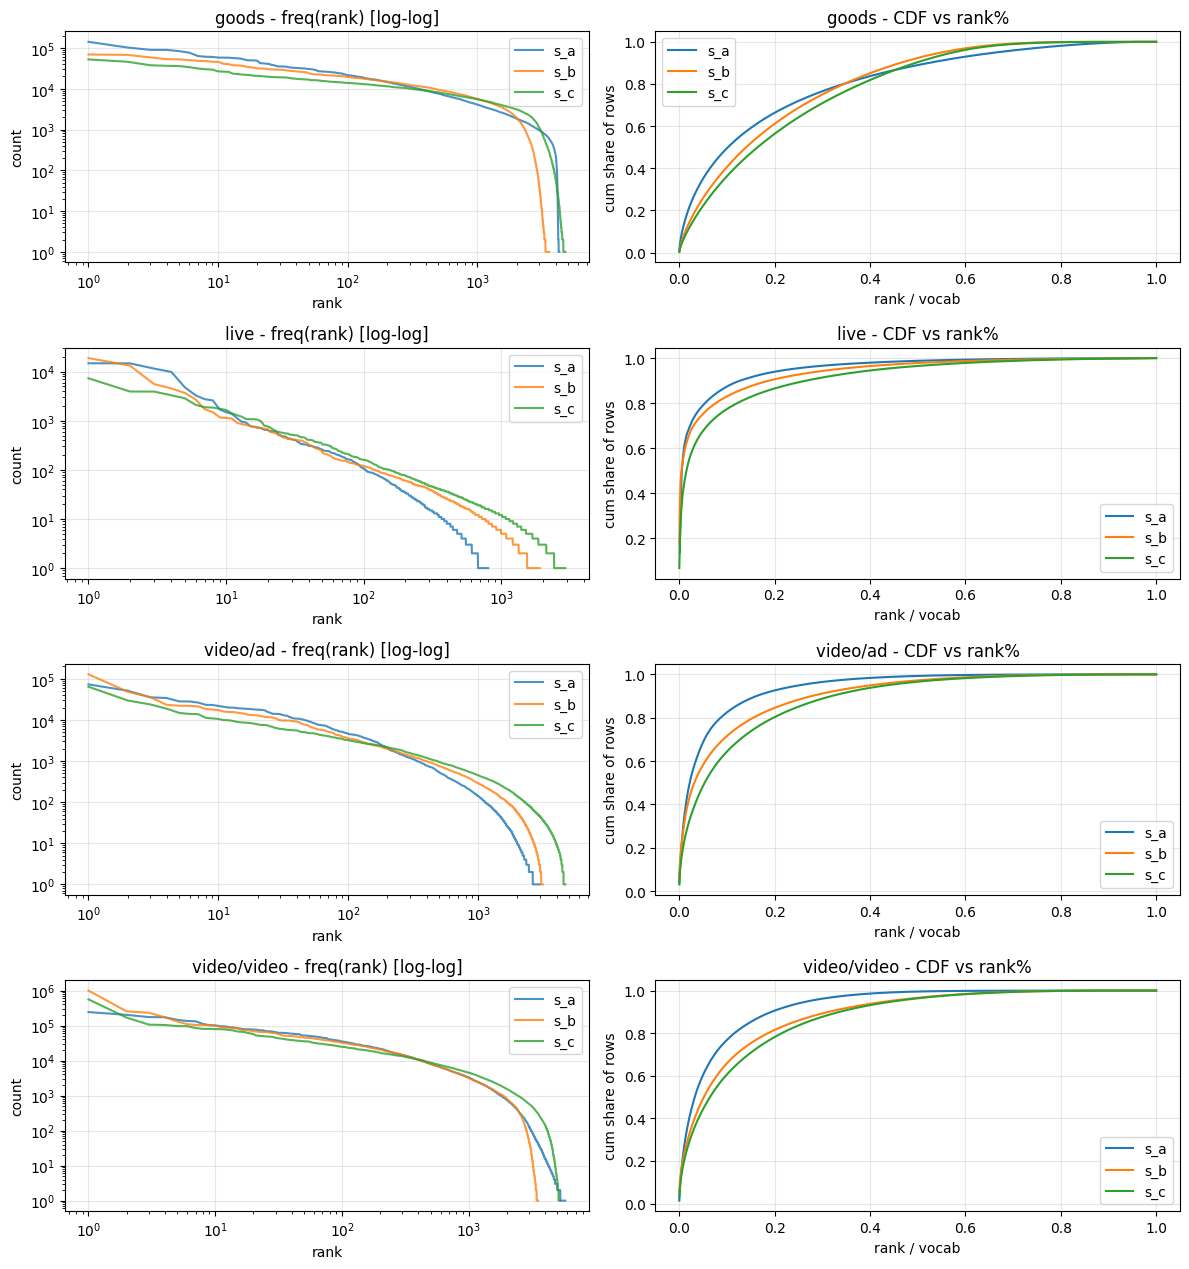

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/freq_curves.png


In [16]:
# 每 domain 一张图，画 s_a / s_b / s_c 的频率排序（log-log） + CDF
domains = sorted(stats['freq'].keys())
n = len(domains)
fig, axes = plt.subplots(n, 2, figsize=(12, 3.2 * n), squeeze=False)
for i, domain in enumerate(domains):
    ax_pdf = axes[i][0]; ax_cdf = axes[i][1]
    for lvl_idx, lvl in enumerate(LEVELS):
        arr = freq_arrays.get((domain, lvl))
        if arr is None or arr.size == 0:
            continue
        rank = np.arange(1, arr.size + 1)
        ax_pdf.loglog(rank, arr, label=lvl, alpha=0.8)
        cdf = np.cumsum(arr) / arr.sum()
        ax_cdf.plot(rank / arr.size, cdf, label=lvl)
    ax_pdf.set_title(f'{domain} - freq(rank) [log-log]')
    ax_pdf.set_xlabel('rank'); ax_pdf.set_ylabel('count'); ax_pdf.legend(); ax_pdf.grid(alpha=0.3)
    ax_cdf.set_title(f'{domain} - CDF vs rank%')
    ax_cdf.set_xlabel('rank / vocab'); ax_cdf.set_ylabel('cum share of rows'); ax_cdf.legend(); ax_cdf.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'freq_curves.png', dpi=110)
plt.show()
print('saved:', OUT_DIR / 'freq_curves.png')

In [17]:
# 每 domain × level 单独导出频次直方图（token_id, count）
for domain, level_counters in stats['freq'].items():
    for lvl_idx, cnt in enumerate(level_counters):
        if not cnt:
            continue
        df = pd.DataFrame({'token_id': list(cnt.keys()), 'count': list(cnt.values())})
        df = df.sort_values('count', ascending=False).reset_index(drop=True)
        safe = domain.replace('/', '_')
        out = OUT_DIR / f'freq_hist_{safe}_{LEVELS[lvl_idx]}.csv'
        df.to_csv(out, index=False)
print('all freq_hist_*.csv written to', OUT_DIR)

all freq_hist_*.csv written to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid


## §2.1.3 联合分布 & 层级性 —— `s_a` 是否强预测 `s_b`？

核心问题：如果层级性显著，推理时可以做 **prefix constrained decoding**：先解出 `s_a`，再限制 `s_b` 只在 `s_a` 出现过的候选中生成，能大幅提升 Pass@64。

衡量方式：
- **平均条件熵** $H(s_b|s_a) = \sum_a P(a) H(s_b|s_a=a)$，与 $H(s_b)$ 对比得到 **信息增益**（越大代表 s_a 越能压缩 s_b 的不确定性）。
- 同理算 $H(s_c|s_a,s_b)$ vs $H(s_c)$。
- 每个 s_a 桶下 s_b 的 **平均 unique 数**（越小说明层级越干净）。

In [18]:
def entropy_from_counts(counts):
    total = sum(counts)
    if total == 0:
        return 0.0
    p = np.array(counts, dtype=np.float64) / total
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

hier_rows = []
for domain in sorted(stats['freq']):
    fq = stats['freq'][domain]
    H_a = entropy_from_counts(list(fq[0].values()))
    H_b = entropy_from_counts(list(fq[1].values()))
    H_c = entropy_from_counts(list(fq[2].values()))

    # H(s_b | s_a)
    total_rows = sum(fq[0].values())
    ab = stats['pair_ab'][domain]
    H_b_given_a = 0.0
    b_bucket_sizes = []
    for a_id, b_ctr in ab.items():
        p_a = sum(b_ctr.values()) / total_rows
        H_b_given_a += p_a * entropy_from_counts(list(b_ctr.values()))
        b_bucket_sizes.append(len(b_ctr))

    # H(s_c | s_a, s_b)
    abc = stats['pair_abc'][domain]
    H_c_given_ab = 0.0
    c_bucket_sizes = []
    for _, c_ctr in abc.items():
        p_ab = sum(c_ctr.values()) / total_rows
        H_c_given_ab += p_ab * entropy_from_counts(list(c_ctr.values()))
        c_bucket_sizes.append(len(c_ctr))

    hier_rows.append({
        'domain':               domain,
        'H(s_a)':               round(H_a, 3),
        'H(s_b)':               round(H_b, 3),
        'H(s_c)':               round(H_c, 3),
        'H(s_b|s_a)':           round(H_b_given_a, 3),
        'IG_a→b':               round(H_b - H_b_given_a, 3),
        'H(s_c|s_a,s_b)':       round(H_c_given_ab, 3),
        'IG_(a,b)→c':           round(H_c - H_c_given_ab, 3),
        'avg_uniq_b_per_a':     round(float(np.mean(b_bucket_sizes)), 2) if b_bucket_sizes else 0,
        'p90_uniq_b_per_a':     int(np.percentile(b_bucket_sizes, 90)) if b_bucket_sizes else 0,
        'avg_uniq_c_per_ab':    round(float(np.mean(c_bucket_sizes)), 2) if c_bucket_sizes else 0,
        'p90_uniq_c_per_ab':    int(np.percentile(c_bucket_sizes, 90)) if c_bucket_sizes else 0,
    })

hier_df = pd.DataFrame(hier_rows)
hier_df.to_csv(OUT_DIR / 'hierarchy_entropy.csv', index=False)
print('saved:', OUT_DIR / 'hierarchy_entropy.csv')
hier_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/hierarchy_entropy.csv


,domain,H(s_a),H(s_b),H(s_c),H(s_b|s_a),IG_a→b,"H(s_c|s_a,s_b)","IG_(a,b)→c",avg_uniq_b_per_a,p90_uniq_b_per_a,avg_uniq_c_per_ab,p90_uniq_c_per_ab
0,goods,10.941,10.812,11.367,8.031,2.781,3.716,7.651,452.57,907,5.32,11
1,live,5.616,6.766,8.469,5.037,1.729,4.175,4.294,25.99,67,2.98,5
2,video/ad,8.593,9.165,10.236,6.484,2.681,3.981,6.255,86.04,235,4.18,7
3,video/video,9.929,9.719,10.560,7.548,2.171,5.014,5.546,235.05,703,7.62,15


In [19]:
# ===== 三元组碰撞率：不同 pid 是否共享同一个 (s_a,s_b,s_c) =====
coll_rows = []
for domain, tri_ctr in sorted(stats['triple_cnt'].items()):
    total_pids = sum(tri_ctr.values())
    unique_triples = len(tri_ctr)
    max_share = max(tri_ctr.values()) if tri_ctr else 0
    shared = sum(1 for v in tri_ctr.values() if v > 1)
    shared_rows = sum(v for v in tri_ctr.values() if v > 1)
    coll_rows.append({
        'domain':                    domain,
        'total_pids':                total_pids,
        'unique_triples':            unique_triples,
        'triples_shared_by_multi_pid': shared,
        'shared_triples_%':          round(shared / max(1, unique_triples) * 100, 2),
        'shared_pids_%':             round(shared_rows / max(1, total_pids) * 100, 2),
        'max_pids_per_triple':       max_share,
        'pids_per_triple_avg':       round(total_pids / max(1, unique_triples), 3),
    })
coll_df = pd.DataFrame(coll_rows)
coll_df.to_csv(OUT_DIR / 'triple_collision.csv', index=False)
print('saved:', OUT_DIR / 'triple_collision.csv')
coll_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/sid/triple_collision.csv


,domain,total_pids,unique_triples,triples_shared_by_multi_pid,shared_triples_%,shared_pids_%,max_pids_per_triple,pids_per_triple_avg
0,goods,16087726,10295563,2080061,20.20,48.93,2996,1.563
1,live,107289,62070,9947,16.03,51.42,673,1.729
2,video/ad,2056889,1069596,269189,25.17,61.09,3460,1.923
3,video/video,17662191,10345920,2156091,20.84,53.63,4523,1.707


## §2.1.4 跨域共现

同一 `(s_a, s_b, s_c)` 三元组是否同时出现在多个 domain？如果几乎完全隔离，说明每个 domain 有独立的 codebook；如果重叠严重，说明 codebook 是共享的（那么在生成侧只有 `<|domain_begin|>` 前缀 token 决定域，模型可以跨域迁移）。

> 为控制内存，扫描时对三元组做了 hash 采样（约 1%），在此基础上估算跨域重叠比例。

=== 跨 domain 三元组重叠矩阵（基于 hash 抽样，比例意义）===
              goods  live  video/ad  video/video
goods        102843     0         1            1
live              0   623         0           57
video/ad          1     0     10745         2907
video/video       1    57      2907       103493

=== 三元组分布：出现在几个 domain 中 ===
  出现在 1 个 domain:    211,775 个三元组   (98.62%)
  出现在 2 个 domain:      2,963 个三元组   (1.38%)
  出现在 3 个 domain:          1 个三元组   (0.00%)


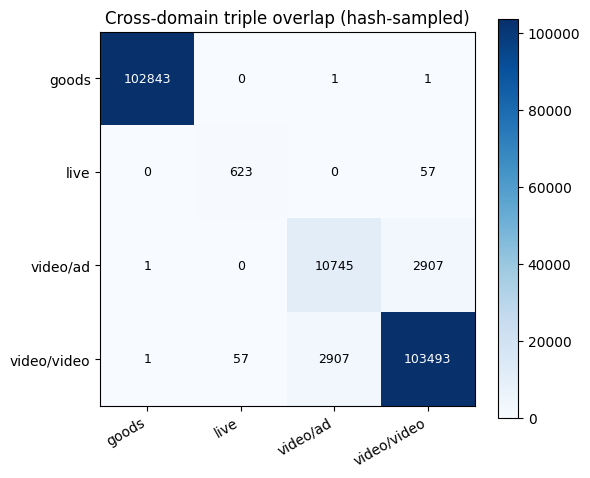

In [20]:
domains = sorted(stats['freq'].keys())
# 跨域共现矩阵：M[da][db] = 同一三元组同时在 da 和 db 出现的样本数（用采样估计）
M = pd.DataFrame(0, index=domains, columns=domains, dtype=int)
multi_domain_share = Counter()  # #domains → 三元组个数
for triple, dset in stats['triple_domains'].items():
    dset = list(dset)
    multi_domain_share[len(dset)] += 1
    for i, d1 in enumerate(dset):
        for d2 in dset[i:]:  # 含对角
            M.loc[d1, d2] += 1
            if d1 != d2:
                M.loc[d2, d1] += 1

print('=== 跨 domain 三元组重叠矩阵（基于 hash 抽样，比例意义）===')
print(M)
M.to_csv(OUT_DIR / 'cross_domain_overlap.csv')

print('\n=== 三元组分布：出现在几个 domain 中 ===')
total_sampled = sum(multi_domain_share.values())
for k in sorted(multi_domain_share):
    v = multi_domain_share[k]
    print(f'  出现在 {k} 个 domain: {v:>10,} 个三元组   ({v/total_sampled*100:.2f}%)')

# 画热力图
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M.values, cmap='Blues')
ax.set_xticks(range(len(domains))); ax.set_xticklabels(domains, rotation=30, ha='right')
ax.set_yticks(range(len(domains))); ax.set_yticklabels(domains)
for i in range(len(domains)):
    for j in range(len(domains)):
        ax.text(j, i, str(M.values[i, j]), ha='center', va='center',
                color='white' if M.values[i, j] > M.values.max()/2 else 'black', fontsize=9)
ax.set_title('Cross-domain triple overlap (hash-sampled)')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'cross_domain_overlap.png', dpi=110)
plt.show()

## §2.1.5 结论 & 对 SFT 的直接指导

把上面各表的关键结论人肉抄进 `analysis/report.md` 的 SID 章节，回答以下问题：

1. **codebook 大小**：`s_a / s_b / s_c` 各是多少？和 tokenizer 里 `<s_a_*>` 的 id 覆盖是否一致（决定要不要新增 special token）。
2. **是否跨域共用**：`vocab_size.csv` 与 `cross_domain_overlap.csv` 对比 —— 如果跨域几乎不重叠，说明每个域的 SID 独立，可以在生成侧强制先解 domain 前缀 token；如果重叠明显，说明 codebook 共享，模型天然支持跨域迁移。
3. **长尾程度**：`freq_summary.csv` 里 `longtail_lt5_%tokens` 高说明存在大量出现 <5 次的 token —— SFT 时对这些 pid 需要 upweight 或让模型先见通用样本再见长尾。
4. **层级性强弱**：`hierarchy_entropy.csv` 里 `IG_a→b` 越大 → prefix constrained decoding 收益越大；`avg_uniq_b_per_a` 反映每个 s_a 桶下 s_b 候选数，直接决定 beam 宽度。
5. **三元组碰撞**：`triple_collision.csv` 里 `shared_triples_%` 高 → 说明多个 pid 会映射到同一 SID，Pass@64 评估时**应把碰撞视为等价**（构造评估集时特别注意）。

**产出物清单**（`analysis/outputs/sid/`）：
- `vocab_size.csv`
- `freq_summary.csv`
- `freq_hist_{domain}_{level}.csv`
- `freq_curves.png`
- `hierarchy_entropy.csv`
- `triple_collision.csv`
- `cross_domain_overlap.csv`
- `cross_domain_overlap.png`
- `_cache.pkl`（中间缓存，供后续 notebook 复用，比如 §2.2 的 join 检查）